# Using CLERO samples

`emu.sample` draws climates from CLERO's joint climate distribution (sample axis first). Because each draw is a coherent whole-map sample, you can run the same downstream calculation on every draw and use the resulting values as CLERO's climate distribution for that derived quantity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from clero import Emulator
from clero.climate_analysis import global_mean, latitude_centers, latitude_weights

INPUTS = {
    "T_star": 3000.0, "F_star": 1000.0, "radius": 1.0, "gravity": 9.8,
    "P_rot": 10.0, "P0": 1.0, "CO2": 4.0e-4, "CH4": 0.0, "GCM": "um",
}
emu = Emulator()
lat = latitude_centers(emu.grid_shape[0])

## Climate distribution of a derived quantity

Compute the same diagnostic on every sampled field. Here, the diagnostic is the area-weighted global-mean surface temperature, so the resulting values form CLERO's climate distribution for that scalar quantity.

In [2]:
samples = emu.sample(INPUTS, n_samples=256, seed=0)
global_means = np.array([global_mean(s, lat) for s in samples["surface_temperature"]])
print(f"global-mean surface T: {global_means.mean():.2f} ± {global_means.std(ddof=1):.2f} K")

global-mean surface T: 242.15 ± 5.74 K


In [3]:
# A wind diagnostic: u(level, lat, lon) -> max over the first five levels of the zonal-mean zonal wind.
u_fields = [f"u_{i}" for i in range(10)]
wind_samples = emu.sample(INPUTS, fields=u_fields, n_samples=128, seed=1)
u_levels = np.stack([wind_samples[field] for field in u_fields], axis=1)  # (sample, level, lat, lon)
max_zonal_mean_zonal_wind = u_levels[:, :5].mean(axis=-1).max(axis=(1, 2))
print(
    "max zonal-mean zonal wind: "
    f"{max_zonal_mean_zonal_wind.mean():.2f} ± {max_zonal_mean_zonal_wind.std(ddof=1):.2f} m/s"
)


max zonal-mean zonal wind: 33.00 ± 2.99 m/s


## Pointwise uncertainty: analytic vs samples

A consistency check, **not** a scalar uncertainty. Both curves below are the *mean pointwise* model-space std — the area-weighted average over the map of each cell's marginal std. The "analytic" line reads it straight off the diagonal `return_variance`; the "samples" line estimates the same quantity from coherent draws. They should agree, which confirms the sampler reproduces the analytic marginals. Neither is the uncertainty of a summary scalar like global-mean surface T — that needs the spatial covariance, and is computed in the next section.

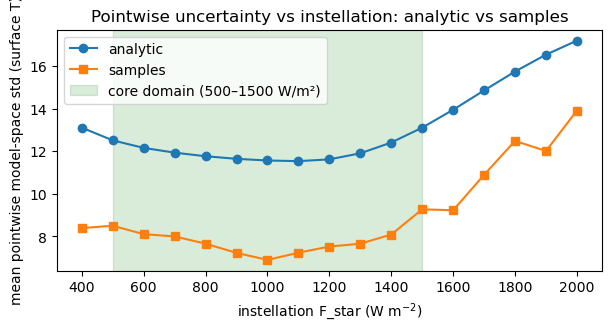

In [4]:
# Pointwise (per-cell, marginal) std vs instellation: analytic diagonal vs sample estimate.
# Both are mean pointwise std, NOT the global-mean scalar's uncertainty (see next section).
fluxes = np.arange(400.0, 2000.0 + 1.0, 100.0)  # inside the extended domain (400–3100 W/m²)
flux_batch = [{**INPUTS, "F_star": float(f_star)} for f_star in fluxes]

_, variance = emu.predict(
    flux_batch,
    fields=["surface_temperature"],
    space="model",
    return_variance=True,
)
surface_variance = variance["surface_temperature"]
w = latitude_weights(lat)
analytic_std = (np.sqrt(surface_variance).mean(axis=2) * w[None]).sum(axis=1)

surface_samples = emu.sample(
    flux_batch,
    fields=["surface_temperature"],
    n_samples=64,
    seed=2,
    space="model",
    batch_size=8,
)["surface_temperature"]
sample_std = (surface_samples.std(axis=0, ddof=1).mean(axis=2) * w[None]).sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.plot(fluxes, analytic_std, marker="o", label="analytic")
ax.plot(fluxes, sample_std, marker="s", label="samples")
ax.axvspan(500.0, 1500.0, alpha=0.15, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="mean pointwise model-space std (surface T)",
    title="Pointwise uncertainty vs instellation: analytic vs samples",
)
ax.legend()
plt.show()


## Uncertainty of a summary scalar (needs samples)

The previous plot averages each cell's marginal std. The uncertainty of the **global-mean surface temperature** is a different quantity: it's the std of $\sum_i w_i T_i$, whose variance is $\sum_{i,j} w_i w_j\,\mathrm{Cov}(T_i, T_j)$ — it depends on how cells co-vary, which the diagonal `return_variance` doesn't carry. The clean way is to push each coherent sample through the scalar diagnostic and take the std of the resulting values. Overlaying it on the mean pointwise std shows they are genuinely different: spatial error cancellation makes the scalar's uncertainty smaller.

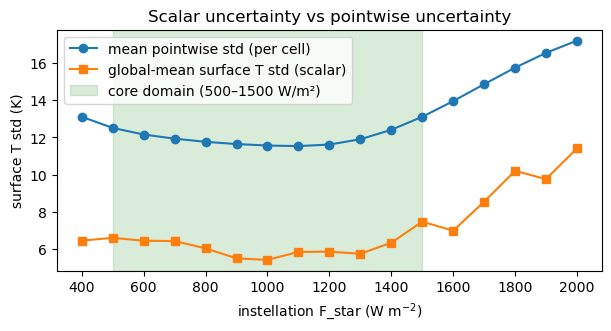

In [5]:
# Covariance-correct: std of the global-mean surface T, estimated from coherent samples.
# Surface temperature is identity-transformed, so model space == physical space here.
scalar_samples = emu.sample(
    flux_batch,
    fields=["surface_temperature"],
    n_samples=64,
    seed=2,
    batch_size=8,
)["surface_temperature"]  # (sample, flux, lat, lon)
global_means = np.array([[global_mean(s, lat) for s in per_flux] for per_flux in scalar_samples.swapaxes(0, 1)])
scalar_std = global_means.std(axis=1, ddof=1)  # std over samples, per flux

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.plot(fluxes, analytic_std, marker="o", label="mean pointwise std (per cell)")
ax.plot(fluxes, scalar_std, marker="s", label="global-mean surface T std (scalar)")
ax.axvspan(500.0, 1500.0, alpha=0.15, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="surface T std (K)",
    title="Scalar uncertainty vs pointwise uncertainty",
)
ax.legend()
plt.show()


## Surface temperature with a predictive band

Most useful for a paper figure: the global-mean surface temperature *itself* versus instellation, with its predictive uncertainty drawn as a shaded band. Reusing the per-sample `global_means`, we take canonical quantiles across the sample axis — the median as the central estimate, with 16–84% (≈1σ) and 2.5–97.5% (≈2σ) bands. The band widens markedly outside the core domain, the same scope-of-validity story seen in the std plots.

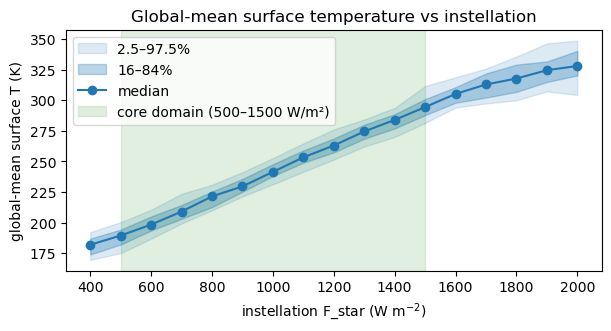

In [6]:
# global_means is (flux, sample) from the previous cell; take canonical quantiles over samples.
lo2, lo1, med, hi1, hi2 = np.quantile(global_means, [0.025, 0.16, 0.5, 0.84, 0.975], axis=1)

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.fill_between(fluxes, lo2, hi2, alpha=0.15, color="C0", label="2.5–97.5%")
ax.fill_between(fluxes, lo1, hi1, alpha=0.30, color="C0", label="16–84%")
ax.plot(fluxes, med, color="C0", marker="o", label="median")
ax.axvspan(500.0, 1500.0, alpha=0.12, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="global-mean surface T (K)",
    title="Global-mean surface temperature vs instellation",
)
ax.legend()
plt.show()


## Summarising skewed fields correctly

For nonlinearly-transformed variables (humidity, cloud fraction, ...) the climate distribution is skewed in physical space, so a physical mean ± std is misleading — the std can run past zero. Compute summaries in **model** space (where it's Gaussian), then inverse-transform the summary with `to_physical`. Quantiles map exactly under the transform, giving a physical median and an asymmetric, always-positive interval. Identity-transform fields like surface temperature are unaffected.

In [7]:
field = "specific_humidity_5"
model_draws = emu.sample(INPUTS, n_samples=256, seed=0, space="model")[field]
mu, sd = model_draws.mean(0), model_draws.std(0, ddof=1)

# inverse-transform the model-space (mean - sd, mean, mean + sd) to physical 16/50/84
band = emu.to_physical(field, np.stack([mu - sd, mu, mu + sd]), INPUTS)
lo, med, hi = (float(b.mean()) for b in band)
print(f"via model space  16/50/84: {lo:.2e} / {med:.2e} / {hi:.2e}  (asymmetric, all > 0)")

naive = emu.sample(INPUTS, n_samples=256, seed=0)[field]
print(f"naive physical   mean±std: {naive.mean():.2e} ± {naive.std():.2e}  (std implies negatives)")

via model space  16/50/84: 8.89e-05 / 1.85e-04 / 3.86e-04  (asymmetric, all > 0)


naive physical   mean±std: 2.41e-04 ± 4.69e-04  (std implies negatives)


## Subset fields for speed and memory

Pass `fields=[...]` to compute and return only the outputs you need — a real saving when you draw many samples but care about one or two fields.

In [8]:
surface_only = emu.sample(INPUTS, fields=["surface_temperature"], n_samples=256)
print("returned fields:", list(surface_only))
print("shape:", surface_only["surface_temperature"].shape)

returned fields: ['surface_temperature']
shape: (256, 32, 64)


## Large sweeps

For many planets at once, pass a batch (a list of dicts or a column dict) and tune `batch_size`. On a CUDA machine, `Emulator(device="cuda")` runs the same call on the GPU.